# Feature-Based Object Tracking
## Harris Corner Detection + Lucas–Kanade Optical Flow

**Course:** Computer Vision  
**Group Members:** 23L-2543 | 23L-2589

---

### Pipeline Overview
1. Read video frames
2. User selects bounding box on first frame
3. Detect Harris corners **inside** the bounding box
4. Track corners across frames using **Lucas–Kanade optical flow**
5. Filter unreliable tracked points
6. Detect object loss → pause tracking
7. Re-detect when object reappears
8. Update object bounding box / centroid each frame
9. Save annotated output video

---
## 0 · Setup & Imports

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display
import ipywidgets as widgets
import os

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy  version : {np.__version__}")

OpenCV version : 4.13.0
NumPy  version : 2.0.2


---
## 1 · Configuration

In [97]:
# ── Paths ──────────────────────────────────────────────────────────────────────
VIDEO_PATH  = "input_video.mp4"
OUTPUT_PATH = "tracked_output.mp4"

# ── Harris Corner Detector Parameters ─────────────────────────────────────────
HARRIS_BLOCK_SIZE   = 5
HARRIS_KSIZE        = 3
HARRIS_K            = 0.04
HARRIS_THRESH_RATIO = 0.10      # ← LOWER for more corners
HARRIS_MIN_DIST     = 10
MAX_CORNERS         = 150       # ← MORE points

# ── Lucas-Kanade Optical Flow Parameters ──────────────────────────────────────
LK_WIN_SIZE  = (41, 41)         # ← LARGER window
LK_MAX_LEVEL = 6                # ← MORE pyramid levels (critical!)
LK_CRITERIA  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 50, 0.01)  # ← MORE iterations

# ── Tracking / Loss Detection Parameters ──────────────────────────────────────
MAX_POINT_DRIFT      = 60.0     # ← HIGHER tolerance
MIN_POINTS_TO_TRACK  = 4
MAX_BBOX_DRIFT       = 350      # ← HIGHER bbox jump tolerance
LOST_REDETECT_EVERY  = 10       # ← FASTER redetection attempts
MIN_REDETECT_CORNERS = 5

# ── Display ────────────────────────────────────────────────────────────────────
BBOX_COLOR     = (0, 255, 0)
LOST_COLOR     = (0, 0, 255)
POINT_COLOR    = (0, 0, 255)
CENTROID_COLOR = (255, 0, 0)

print("Configuration loaded.")

Configuration loaded.


---
## 2 · Video Utilities

Video info:
  width     : 1080
  height    : 1920
  fps       : 29.97370727432077
  frames    : 228


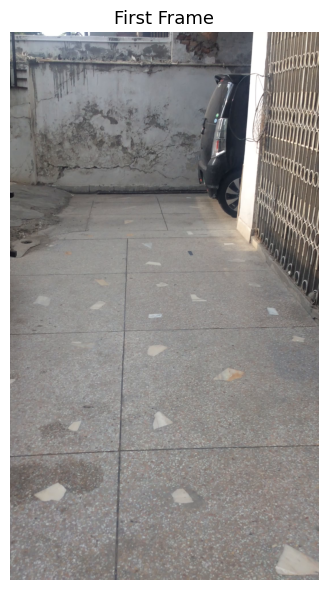

In [98]:
def open_video(path):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {path}")
    return cap

def get_video_info(cap):
    return {
        "width"  : int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height" : int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fps"    : cap.get(cv2.CAP_PROP_FPS),
        "frames" : int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    }

def read_first_frame(path):
    cap = open_video(path)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError("Could not read first frame.")
    return frame

def show_frame(frame_bgr, title="", figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

cap  = open_video(VIDEO_PATH)
info = get_video_info(cap)
cap.release()
print("Video info:")
for k, v in info.items():
    print(f"  {k:<10}: {v}")

first_frame = read_first_frame(VIDEO_PATH)
show_frame(first_frame, "First Frame")

---
## 3 · Harris Corner Detector

The Harris response at each pixel is:
$$R = \det(M) - k \cdot \text{trace}(M)^2$$
where $M$ is the structure tensor built from image gradients $I_x$, $I_y$.
Points where $R > 0$ are corners; we keep the strongest via non-maximum suppression.

In [99]:
def compute_harris_response(gray):
    """Compute and dilate the Harris corner response map."""
    gray_f   = np.float32(gray)
    response = cv2.cornerHarris(gray_f, HARRIS_BLOCK_SIZE, HARRIS_KSIZE, HARRIS_K)
    response = cv2.dilate(response, None)
    return response

def non_max_suppression(response, min_dist):
    """Keep only local maxima separated by at least min_dist pixels."""
    h, w       = response.shape
    coords     = np.argwhere(response > 0)
    coords     = sorted(coords, key=lambda p: response[p[0], p[1]], reverse=True)
    kept       = []
    suppressed = np.zeros((h, w), dtype=bool)
    for r, c in coords:
        if suppressed[r, c]:
            continue
        kept.append((c, r))
        r0 = max(0, r-min_dist);  r1 = min(h, r+min_dist+1)
        c0 = max(0, c-min_dist);  c1 = min(w, c+min_dist+1)
        suppressed[r0:r1, c0:c1] = True
    return kept

def detect_harris_corners(gray, bbox=None, max_pts=MAX_CORNERS):
    """
    Detect Harris corners, optionally restricted to a bounding box.
    Returns (N, 1, 2) float32 array compatible with cv2 LK.
    """
    if bbox is not None:
        x, y, bw, bh = bbox
        x  = max(0, x);  y  = max(0, y)
        bw = min(bw, gray.shape[1]-x)
        bh = min(bh, gray.shape[0]-y)
        if bw <= 0 or bh <= 0:
            return np.empty((0,1,2), dtype=np.float32)
        roi = gray[y:y+bh, x:x+bw]
    else:
        roi = gray
        x, y = 0, 0

    response  = compute_harris_response(roi)
    threshold = HARRIS_THRESH_RATIO * response.max()
    response  = np.where(response > threshold, response, 0)
    corners   = non_max_suppression(response, HARRIS_MIN_DIST)
    corners   = [(cx+x, cy+y) for cx, cy in corners][:max_pts]

    if not corners:
        return np.empty((0,1,2), dtype=np.float32)
    return np.array(corners, dtype=np.float32).reshape(-1, 1, 2)

print("Harris corner functions defined.")

Harris corner functions defined.


---
## 4 · Lucas-Kanade Optical Flow Tracker

In [100]:
def track_points_lk(prev_gray, curr_gray, prev_pts):
    """
    Run Lucas-Kanade optical flow. Returns (prev_good, curr_good) — (N,2) float32.
    Filters: LK convergence status + max displacement threshold.
    """
    if len(prev_pts) == 0:
        return np.empty((0,2), dtype=np.float32), np.empty((0,2), dtype=np.float32)

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, prev_pts, None,
        winSize=LK_WIN_SIZE, maxLevel=LK_MAX_LEVEL, criteria=LK_CRITERIA
    )

    good_mask = status.ravel() == 1
    prev_good = prev_pts.reshape(-1,2)[good_mask]
    curr_good = curr_pts.reshape(-1,2)[good_mask]

    if len(prev_good) > 0:
        disp      = np.linalg.norm(curr_good - prev_good, axis=1)
        in_range  = disp < MAX_POINT_DRIFT
        prev_good = prev_good[in_range]
        curr_good = curr_good[in_range]

    return prev_good, curr_good

print("LK tracker defined.")

LK tracker defined.


---
## 5 · Bounding Box Estimation & Object Loss Detection

In [101]:
def estimate_bbox(points):
    """Compute axis-aligned bbox enclosing all tracked points."""
    if len(points) < 2:
        return None
    pad  = 5
    xmin = int(points[:,0].min()) - pad
    ymin = int(points[:,1].min()) - pad
    xmax = int(points[:,0].max()) + pad
    ymax = int(points[:,1].max()) + pad
    return (xmin, ymin, xmax-xmin, ymax-ymin)

def bbox_centre(bbox):
    x, y, w, h = bbox
    return (x + w//2, y + h//2)

def compute_centroid(points):
    if len(points) == 0:
        return None
    return (int(points[:,0].mean()), int(points[:,1].mean()))

def is_bbox_out_of_frame(bbox, frame_w, frame_h, margin=20):
    if bbox is None:
        return True
    cx, cy = bbox_centre(bbox)
    return (cx < -margin or cx > frame_w + margin or
            cy < -margin or cy > frame_h + margin)

def is_object_lost(curr_pts, curr_bbox, prev_bbox, frame_w, frame_h):
    """
    Object is lost if:
      - Too few tracked points remain
      - Bbox centre jumped too far in one frame (sudden drift)
      - Bbox centre moved outside the frame
    Returns (bool, reason_string)
    """
    if len(curr_pts) < MIN_POINTS_TO_TRACK:
        return True, "too_few_points"
    if curr_bbox is not None and prev_bbox is not None:
        cc  = np.array(bbox_centre(curr_bbox))
        pc  = np.array(bbox_centre(prev_bbox))
        if np.linalg.norm(cc - pc) > MAX_BBOX_DRIFT:
            return True, "bbox_drift"
    if is_bbox_out_of_frame(curr_bbox, frame_w, frame_h):
        return True, "out_of_frame"
    return False, None

print("BBox & loss detection defined.")

BBox & loss detection defined.


---
## 6 · Frame Annotation

In [114]:
def annotate_frame(frame, points, bbox, centroid, frame_id, n_points, is_lost=False):
    out = frame.copy()

    for pt in points:
        cv2.circle(out, (int(pt[0]), int(pt[1])), 3, POINT_COLOR, -1)

    if bbox is not None:
        x, y, w, h = bbox
        color = LOST_COLOR if is_lost else BBOX_COLOR
        cv2.rectangle(out, (x, y), (x+w, y+h), color, 2)
        if is_lost:
            cv2.putText(out, "LOST", (x, y-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, LOST_COLOR, 2)

    if centroid is not None:
        cv2.drawMarker(out, centroid, CENTROID_COLOR,
                       cv2.MARKER_CROSS, markerSize=14, thickness=2)

    cv2.putText(out, f"Frame: {frame_id}",
                (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    cv2.putText(out, f"Points: {n_points}",
                (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
    status_txt = "LOST" if is_lost else "TRACKING"
    status_col = LOST_COLOR if is_lost else (0, 255, 0)
    cv2.putText(out, status_txt,
                (10, 76), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_col, 2)
    return out

print("Frame annotation defined.")

Frame annotation defined.


---
## 7 · Bounding Box Selection

Look at the frame, note the coordinates from the axis, fill in the boxes, click **Confirm BBox**.

In [115]:
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"Total frames: {total_frames}")

style = {'description_width': '80px'}
frame_slider = widgets.IntSlider(
    value=0, min=0, max=total_frames-1, step=1,
    description='Frame #:', style=style,
    layout=widgets.Layout(width='400px'),
    continuous_update=False
)

Total frames: 177


Total frames: 177


Output()

Button(button_style='success', description='Confirm BBox', style=ButtonStyle())

Output()

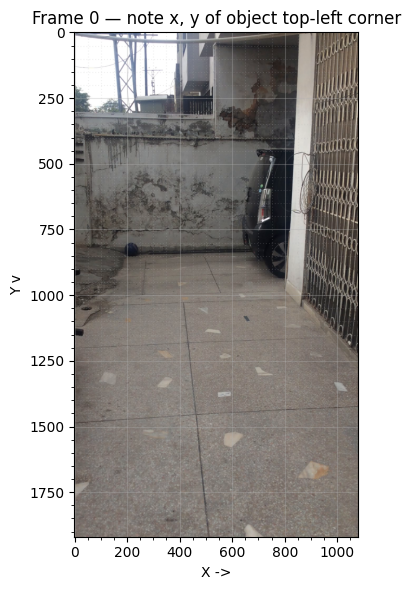

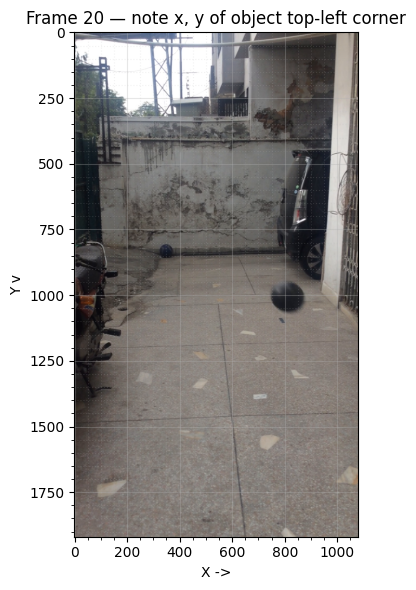

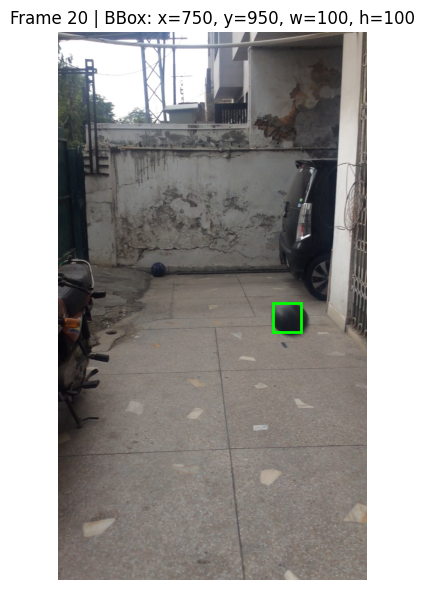

START_FRAME = 20, INITIAL_BBOX = (750, 950, 100, 100)


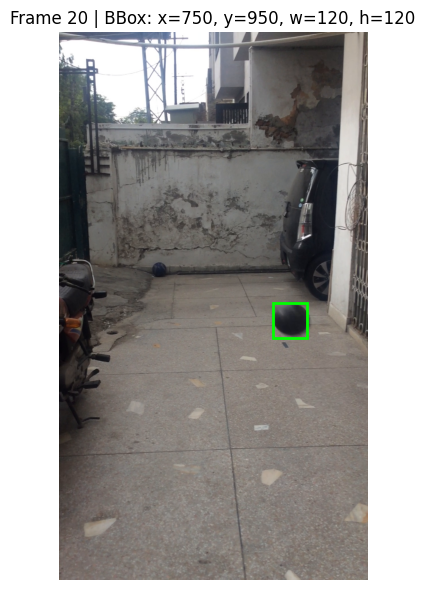

START_FRAME = 20, INITIAL_BBOX = (750, 950, 120, 120)


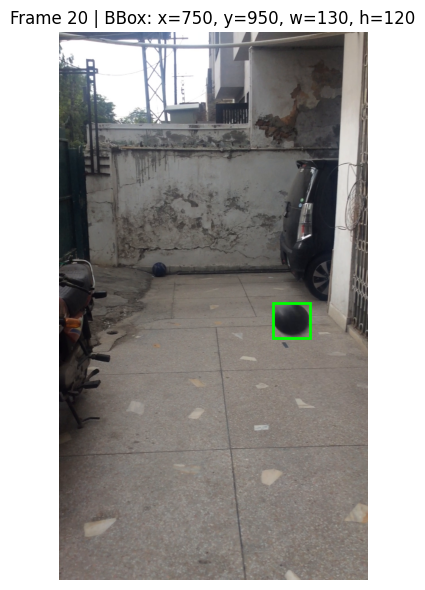

START_FRAME = 20, INITIAL_BBOX = (750, 950, 130, 120)


In [123]:
def read_frame_at(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_idx}")
    return frame

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"Total frames: {total_frames}")

style = {'description_width': '80px'}
frame_slider = widgets.IntSlider(
    value=0, min=0, max=total_frames-1, step=1,
    description='Frame #:', style=style,
    layout=widgets.Layout(width='400px'),
    continuous_update=False
)
frame_input = widgets.IntText(
    value=0, min=0, max=total_frames-1,
    description='Jump to:', style=style,
    layout=widgets.Layout(width='150px')
)
x_box = widgets.IntText(value=100, description='x', style=style, layout=widgets.Layout(width='150px'))
y_box = widgets.IntText(value=100, description='y', style=style, layout=widgets.Layout(width='150px'))
w_box = widgets.IntText(value=200, description='width', style=style, layout=widgets.Layout(width='150px'))
h_box = widgets.IntText(value=300, description='height', style=style, layout=widgets.Layout(width='150px'))
btn = widgets.Button(description='Confirm BBox', button_style='success')
frame_out = widgets.Output()
bbox_out = widgets.Output()

def update_frame(change):
    frame_idx = change['new']
    frame = read_frame_at(VIDEO_PATH, frame_idx)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Clear previous bbox when frame changes
    with bbox_out:
        bbox_out.clear_output(wait=True)

    with frame_out:
        frame_out.clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title(f"Frame {frame_idx} — note x, y of object top-left corner")
        plt.xlabel("X ->"); plt.ylabel("Y v")
        plt.grid(True, alpha=0.3, which='both')
        plt.minorticks_on()
        plt.grid(which='minor', alpha=0.15, linestyle=':')
        plt.tight_layout(); plt.show()

def sync_slider_to_input(change):
    frame_slider.value = frame_input.value

def sync_input_to_slider(change):
    frame_input.value = frame_slider.value

frame_slider.observe(update_frame, names='value')
frame_slider.observe(sync_input_to_slider, names='value')
frame_input.observe(sync_slider_to_input, names='value')

def on_confirm(b):
    global INITIAL_BBOX, START_FRAME
    START_FRAME = frame_slider.value
    INITIAL_BBOX = (x_box.value, y_box.value, w_box.value, h_box.value)
    frame = read_frame_at(VIDEO_PATH, START_FRAME)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    with bbox_out:
        bbox_out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(frame_rgb)
        rect = patches.Rectangle(
            (x_box.value, y_box.value), w_box.value, h_box.value,
            linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.set_title(f"Frame {START_FRAME} | BBox: x={x_box.value}, y={y_box.value}, w={w_box.value}, h={h_box.value}")
        ax.axis('off'); plt.tight_layout(); plt.show()
        print(f"START_FRAME = {START_FRAME}, INITIAL_BBOX = {INITIAL_BBOX}")

btn.on_click(on_confirm)

display(widgets.HBox([frame_slider, frame_input]))
display(frame_out)
display(widgets.HBox([x_box, y_box, w_box, h_box]), btn, bbox_out)

# Trigger initial frame display
update_frame({'new': 0})

---
## 8 · Initial Harris Corner Visualisation

Harris corners detected inside ROI: 4


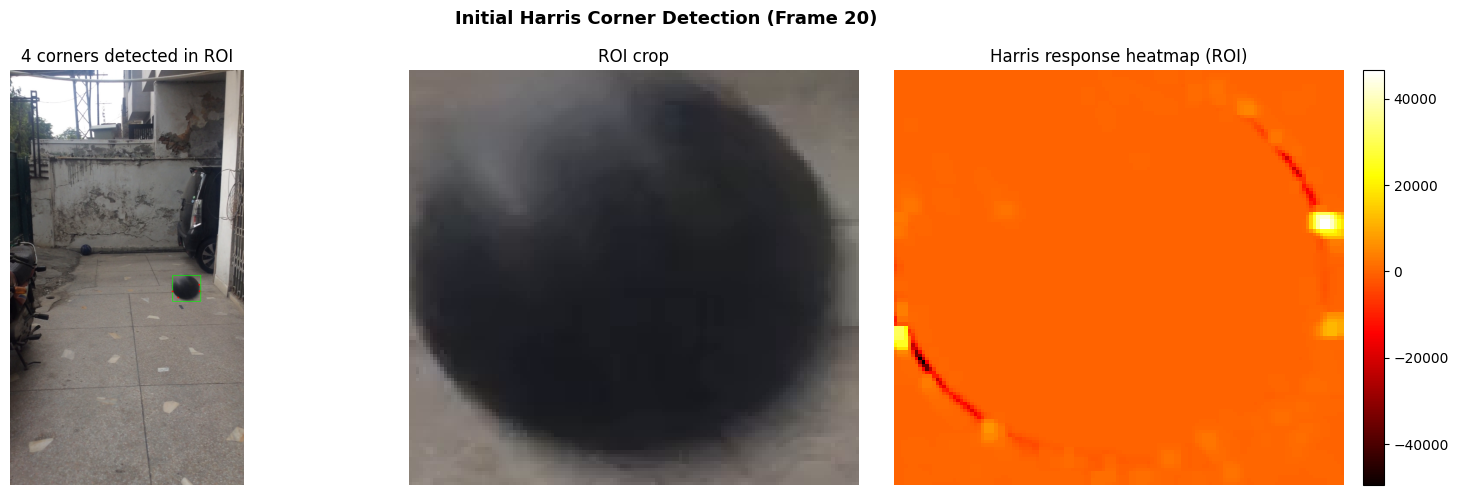

Saved: harris_initial.png


In [124]:
start_frame = read_frame_at(VIDEO_PATH, START_FRAME)
start_gray  = cv2.cvtColor(start_frame, cv2.COLOR_BGR2GRAY)
initial_pts = detect_harris_corners(start_gray, bbox=INITIAL_BBOX)
print(f"Harris corners detected inside ROI: {len(initial_pts)}")

vis = start_frame.copy()
x, y, bw, bh = INITIAL_BBOX
cv2.rectangle(vis, (x,y), (x+bw, y+bh), BBOX_COLOR, 2)
for pt in initial_pts.reshape(-1, 2):
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 4, POINT_COLOR, -1)

roi_gray = start_gray[y:y+bh, x:x+bw]
response = compute_harris_response(roi_gray)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Initial Harris Corner Detection (Frame {START_FRAME})", fontsize=13, fontweight='bold')

axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"{len(initial_pts)} corners detected in ROI")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(start_frame[y:y+bh, x:x+bw], cv2.COLOR_BGR2RGB))
axes[1].set_title("ROI crop")
axes[1].axis('off')

im = axes[2].imshow(response, cmap='hot')
axes[2].set_title("Harris response heatmap (ROI)")
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("harris_initial.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: harris_initial.png")

---
## 9 · Main Tracking Loop

Implements the full pipeline with:
- **Loss detection** (too few points / bbox drift / out-of-frame)
- **Automatic re-detection** every `LOST_REDETECT_EVERY` frames when lost
- Red `LOST` label on frame when object is not tracked

In [125]:
def run_tracker(video_path, output_path, initial_bbox, start_frame=0):
    cap  = open_video(video_path)
    meta = get_video_info(cap)
    fw, fh = meta['width'], meta['height']

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, meta['fps'], (fw, fh))

    # Skip to start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    ret, first_frame = cap.read()
    if not ret:
        cap.release(); writer.release()
        raise RuntimeError(f"Cannot read frame {start_frame}.")

    prev_gray         = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
    prev_pts          = detect_harris_corners(prev_gray, bbox=initial_bbox)
    curr_bbox         = initial_bbox
    prev_bbox         = initial_bbox
    object_lost       = False
    frames_since_lost = 0

    log = {
        "centroids"    : [],
        "point_counts" : [],
        "bboxes"       : [],
        "lost_flags"   : [],
    }

    # Write first frame
    centroid = compute_centroid(prev_pts.reshape(-1,2)) if len(prev_pts)>0 else None
    ann = annotate_frame(first_frame, prev_pts.reshape(-1,2),
                         curr_bbox, centroid, start_frame, len(prev_pts), False)
    writer.write(ann)
    log["centroids"].append(centroid)
    log["point_counts"].append(len(prev_pts))
    log["bboxes"].append(curr_bbox)
    log["lost_flags"].append(False)

    frame_id = start_frame + 1

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if object_lost:
            frames_since_lost += 1
            curr_pts = np.empty((0,2), dtype=np.float32)

            if frames_since_lost % LOST_REDETECT_EVERY == 0:
                if curr_bbox is not None:
                    expand = 40
                    sx = max(0, curr_bbox[0]-expand)
                    sy = max(0, curr_bbox[1]-expand)
                    sw = min(curr_bbox[2]+2*expand, fw-sx)
                    sh = min(curr_bbox[3]+2*expand, fh-sy)
                    search_bbox = (sx, sy, sw, sh)
                else:
                    search_bbox = None

                new_pts = detect_harris_corners(curr_gray, bbox=search_bbox)
                if len(new_pts) >= MIN_REDETECT_CORNERS:
                    prev_pts          = new_pts
                    object_lost       = False
                    frames_since_lost = 0
                    curr_pts          = new_pts.reshape(-1,2)
                    print(f"  [Frame {frame_id}] Object re-detected ({len(new_pts)} corners)")

            ann = annotate_frame(frame, curr_pts, curr_bbox, None,
                                 frame_id, 0, is_lost=True)

        else:
            _, curr_pts = track_points_lk(prev_gray, curr_gray, prev_pts)
            new_bbox    = estimate_bbox(curr_pts)
            lost, reason = is_object_lost(curr_pts, new_bbox, prev_bbox, fw, fh)

            if lost:
                object_lost       = True
                frames_since_lost = 0
                print(f"  [Frame {frame_id}] Object LOST — {reason}")
                ann = annotate_frame(frame, curr_pts, curr_bbox, None,
                                     frame_id, len(curr_pts), is_lost=True)
            else:
                prev_bbox = curr_bbox
                curr_bbox = new_bbox
                centroid  = compute_centroid(curr_pts)
                ann = annotate_frame(frame, curr_pts, curr_bbox, centroid,
                                     frame_id, len(curr_pts), is_lost=False)

        writer.write(ann)
        log["centroids"].append(compute_centroid(curr_pts) if len(curr_pts)>0 else None)
        log["point_counts"].append(len(curr_pts))
        log["bboxes"].append(curr_bbox)
        log["lost_flags"].append(object_lost)

        prev_gray = curr_gray
        if not object_lost and len(curr_pts) > 0:
            prev_pts = curr_pts.reshape(-1,1,2).astype(np.float32)

        frame_id += 1
        if frame_id % 50 == 0:
            status = "LOST" if object_lost else "tracking"
            print(f"  Frame {frame_id}/{meta['frames']} | pts: {len(curr_pts)} | {status}")

    cap.release()
    writer.release()
    print(f"\nDone. Output saved to: {output_path}  ({frame_id - start_frame} frames)")
    return log


tracking_log = run_tracker(VIDEO_PATH, OUTPUT_PATH, INITIAL_BBOX, START_FRAME)

  [Frame 21] Object LOST — too_few_points
  [Frame 31] Object re-detected (5 corners)
  Frame 50/177 | pts: 5 | tracking
  Frame 100/177 | pts: 5 | tracking
  Frame 150/177 | pts: 5 | tracking

Done. Output saved to: tracked_output.mp4  (157 frames)


---
## 10 · Sample Annotated Frames

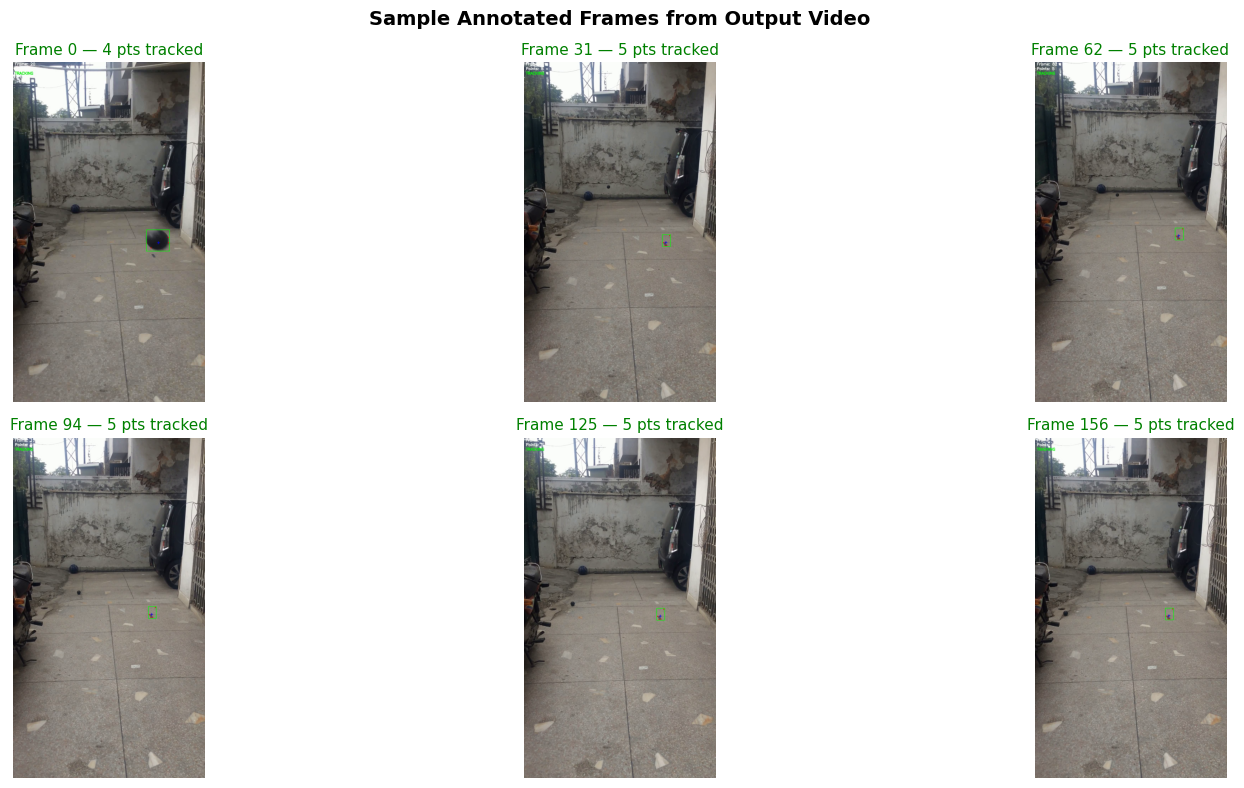

Saved: sample_frames.png


In [126]:
def get_sample_frames(video_path, indices):
    cap    = open_video(video_path)
    result = {}
    fi     = 0
    target = set(indices)
    while True:
        ret, f = cap.read()
        if not ret:
            break
        if fi in target:
            result[fi] = f
        fi += 1
    cap.release()
    return result

total      = len(tracking_log["point_counts"])
sample_ids = sorted(set([0, total//5, 2*total//5, 3*total//5, 4*total//5, total-1]))
frames_dict = get_sample_frames(OUTPUT_PATH, sample_ids)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Sample Annotated Frames from Output Video", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, fid in enumerate(sample_ids[:6]):
    if fid in frames_dict:
        axes[i].imshow(cv2.cvtColor(frames_dict[fid], cv2.COLOR_BGR2RGB))
        lost   = tracking_log['lost_flags'][fid]
        pts    = tracking_log['point_counts'][fid]
        status = "LOST" if lost else f"{pts} pts tracked"
        color  = 'red' if lost else 'green'
        axes[i].set_title(f"Frame {fid} — {status}", fontsize=11, color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("sample_frames.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_frames.png")

---
## 11 · Tracking Statistics

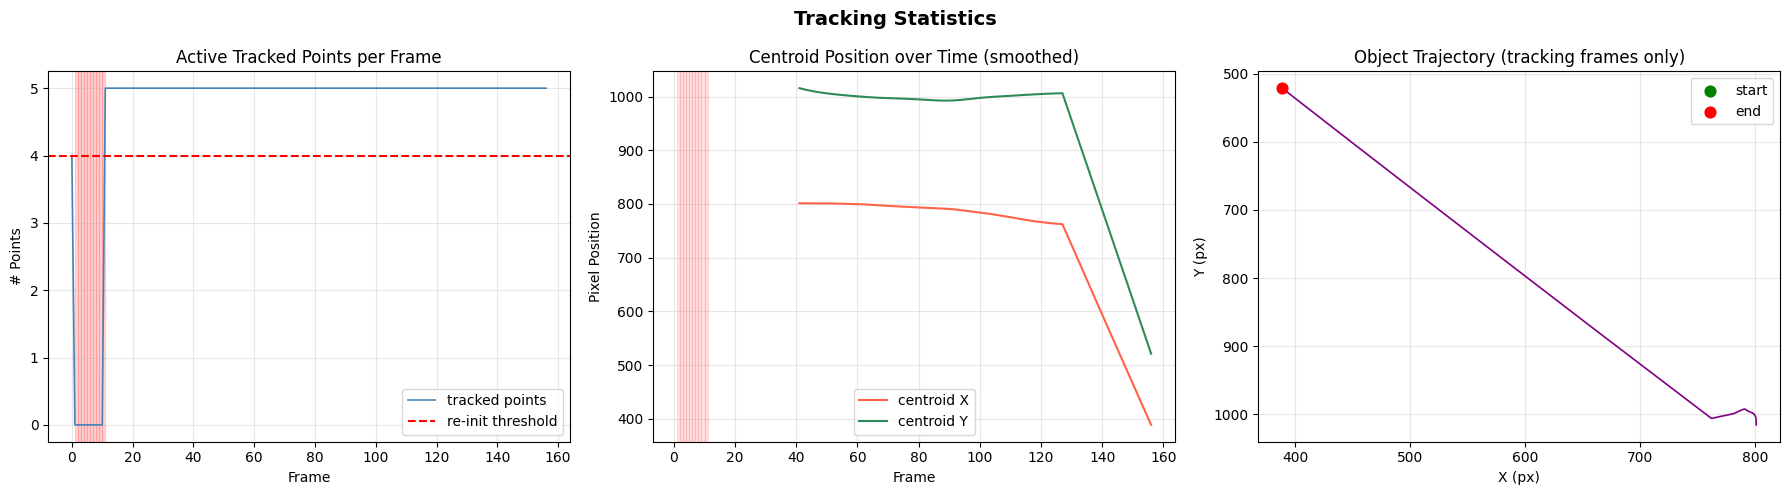

Saved: tracking_analysis.png


In [127]:
frames     = list(range(total))
pt_counts  = tracking_log["point_counts"]
centroids  = tracking_log["centroids"]
lost_flags = tracking_log["lost_flags"]

cx_raw = [c[0] if c is not None else np.nan for c in centroids]
cy_raw = [c[1] if c is not None else np.nan for c in centroids]

def moving_avg(vals, w=60):
    arr    = np.array(vals, dtype=float)
    kernel = np.ones(w) / w
    return np.convolve(arr, kernel, mode='same').tolist()

cx_vals     = moving_avg(cx_raw, w=60)
cy_vals     = moving_avg(cy_raw, w=60)
lost_arr    = np.array(lost_flags)
lost_frames = np.where(lost_arr)[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tracking Statistics", fontsize=14, fontweight='bold')

# Plot 1: point count
axes[0].plot(frames, pt_counts, color='steelblue', linewidth=1.2, label='tracked points')
axes[0].axhline(MIN_POINTS_TO_TRACK, color='red', linestyle='--', label='re-init threshold')
for f in lost_frames:
    axes[0].axvspan(f, f+1, color='red', alpha=0.15)
axes[0].set_title("Active Tracked Points per Frame")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("# Points")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: centroid X/Y
axes[1].plot(frames, cx_vals, color='tomato',   linewidth=1.5, label='centroid X')
axes[1].plot(frames, cy_vals, color='seagreen', linewidth=1.5, label='centroid Y')
for f in lost_frames:
    axes[1].axvspan(f, f+1, color='red', alpha=0.1)
axes[1].set_title("Centroid Position over Time (smoothed)")
axes[1].set_xlabel("Frame"); axes[1].set_ylabel("Pixel Position")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Plot 3: trajectory (tracking frames only, downsampled)
step = max(1, total//300)
track_pts = [(cx_vals[i], cy_vals[i]) for i in range(0, total, step)
             if not lost_flags[i] and not np.isnan(cx_raw[i])]
if track_pts:
    tx, ty = zip(*track_pts)
    axes[2].plot(tx, ty, color='purple', linewidth=1.2)
    axes[2].scatter([tx[0]],  [ty[0]],  color='green', zorder=5, s=60, label='start')
    axes[2].scatter([tx[-1]], [ty[-1]], color='red',   zorder=5, s=60, label='end')
axes[2].set_title("Object Trajectory (tracking frames only)")
axes[2].set_xlabel("X (px)"); axes[2].set_ylabel("Y (px)")
axes[2].invert_yaxis()
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tracking_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tracking_analysis.png")

---
## 12 · Bounding Box Size over Time

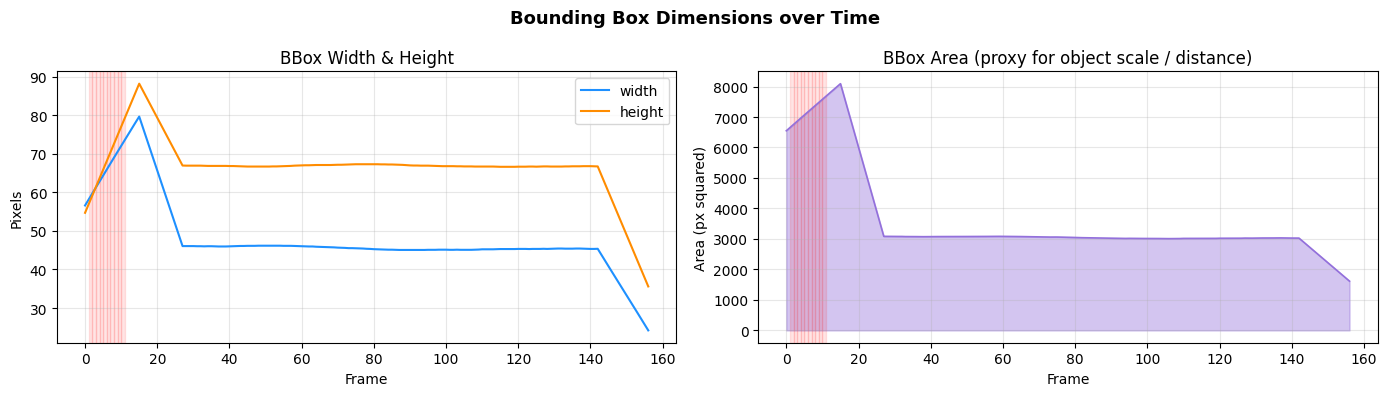

Saved: bbox_size.png


In [128]:
bbox_widths  = [b[2] if b is not None else np.nan for b in tracking_log['bboxes']]
bbox_heights = [b[3] if b is not None else np.nan for b in tracking_log['bboxes']]
bbox_areas   = [w*h if not (np.isnan(w) or np.isnan(h)) else np.nan
                for w,h in zip(bbox_widths, bbox_heights)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Bounding Box Dimensions over Time", fontsize=13, fontweight='bold')

axes[0].plot(frames, moving_avg(bbox_widths, 30),  label='width',  color='dodgerblue')
axes[0].plot(frames, moving_avg(bbox_heights, 30), label='height', color='darkorange')
for f in lost_frames:
    axes[0].axvspan(f, f+1, color='red', alpha=0.1)
axes[0].set_title("BBox Width & Height")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Pixels")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(frames, moving_avg(bbox_areas, 30), color='mediumpurple', alpha=0.4)
axes[1].plot(frames, moving_avg(bbox_areas, 30), color='mediumpurple', linewidth=1.2)
for f in lost_frames:
    axes[1].axvspan(f, f+1, color='red', alpha=0.1)
axes[1].set_title("BBox Area (proxy for object scale / distance)")
axes[1].set_xlabel("Frame"); axes[1].set_ylabel("Area (px squared)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bbox_size.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bbox_size.png")

---
## 13 · Feature Point Density Heatmap

Accumulates the bounding box region across all tracked frames to show **where** the object spent most time in the frame.

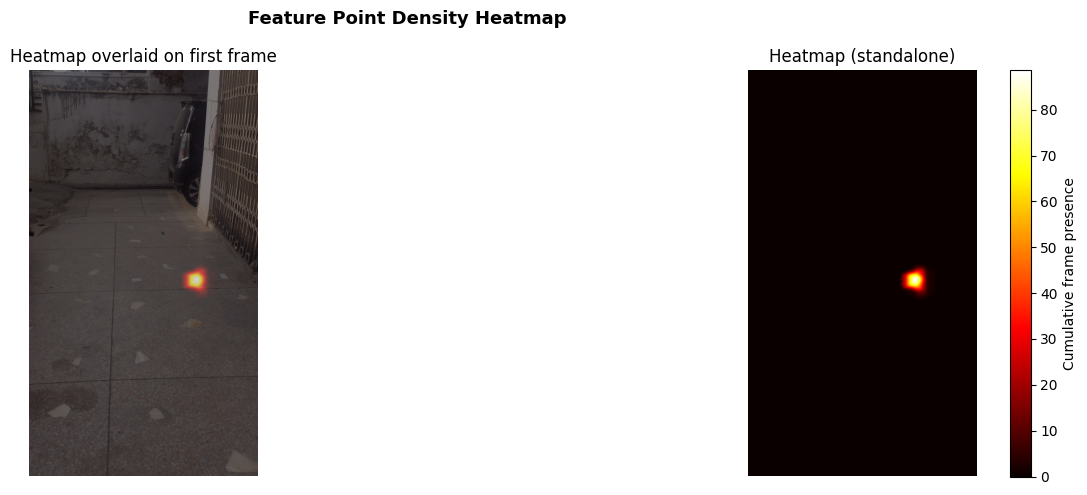

Saved: heatmap.png


In [129]:
heatmap = np.zeros((H_VID, W_VID), dtype=np.float32)

for i, bbox in enumerate(tracking_log['bboxes']):
    if bbox is not None and not tracking_log['lost_flags'][i]:
        x, y, bw, bh = bbox
        x  = max(0, x);  y  = max(0, y)
        bw = min(bw, W_VID-x); bh = min(bh, H_VID-y)
        if bw > 0 and bh > 0:
            heatmap[y:y+bh, x:x+bw] += 1

heatmap_blur = cv2.GaussianBlur(heatmap, (51, 51), 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Point Density Heatmap", fontsize=13, fontweight='bold')

axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].imshow(heatmap_blur, cmap='hot', alpha=0.55)
axes[0].set_title("Heatmap overlaid on first frame")
axes[0].axis('off')

im = axes[1].imshow(heatmap_blur, cmap='hot')
axes[1].set_title("Heatmap (standalone)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='Cumulative frame presence')

plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap.png")

---
## 14 · Loss Event Analysis & Summary

           TRACKING SUMMARY
  Total frames          : 157
  Frames tracked        : 147  (93.6%)
  Frames lost           : 10  (6.4%)
  Loss events           : 1
  Avg tracked pts/frame : 5.0
  Min tracked pts       : 0
  Max tracked pts       : 5

  Loss events:
    #1: frames 1-11  (10 frames)


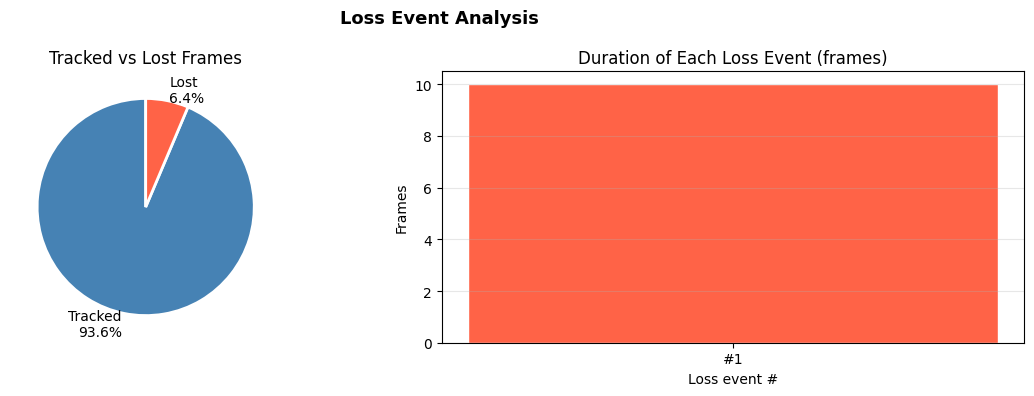

Saved: loss_analysis.png


In [130]:
# Find loss/recovery events
events   = []
in_loss  = False
loss_start = None

for i, lost in enumerate(lost_flags):
    if lost and not in_loss:
        in_loss    = True
        loss_start = i
    elif not lost and in_loss:
        in_loss = False
        events.append({'start': loss_start, 'end': i, 'duration': i - loss_start})
if in_loss:
    events.append({'start': loss_start, 'end': total-1, 'duration': total-1-loss_start})

total_lost    = sum(lost_flags)
total_tracked = total - total_lost
pct_tracked   = 100 * total_tracked / total

print("=" * 50)
print("           TRACKING SUMMARY")
print("=" * 50)
print(f"  Total frames          : {total}")
print(f"  Frames tracked        : {total_tracked}  ({pct_tracked:.1f}%)")
print(f"  Frames lost           : {total_lost}  ({100-pct_tracked:.1f}%)")
print(f"  Loss events           : {len(events)}")
tracked_pts = [p for p,l in zip(pt_counts, lost_flags) if not l]
if tracked_pts:
    print(f"  Avg tracked pts/frame : {np.mean(tracked_pts):.1f}")
print(f"  Min tracked pts       : {min(pt_counts)}")
print(f"  Max tracked pts       : {max(pt_counts)}")
if events:
    print()
    print("  Loss events:")
    for i, e in enumerate(events):
        print(f"    #{i+1}: frames {e['start']}-{e['end']}  ({e['duration']} frames)")
print("=" * 50)

# Pie + bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Loss Event Analysis", fontsize=13, fontweight='bold')

axes[0].pie(
    [total_tracked, total_lost],
    labels=[f'Tracked\n{pct_tracked:.1f}%', f'Lost\n{100-pct_tracked:.1f}%'],
    colors=['steelblue', 'tomato'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title("Tracked vs Lost Frames")

if events:
    durations = [e['duration'] for e in events]
    axes[1].bar(range(len(events)), durations, color='tomato', edgecolor='white')
    axes[1].set_title("Duration of Each Loss Event (frames)")
    axes[1].set_xlabel("Loss event #"); axes[1].set_ylabel("Frames")
    axes[1].set_xticks(range(len(events)))
    axes[1].set_xticklabels([f"#{i+1}" for i in range(len(events))])
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No loss events detected', ha='center', va='center',
                 fontsize=14, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig("loss_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_analysis.png")

In [131]:
# Create structured output folders and zip everything (Google Colab)

import os
import shutil

# Create folders
os.makedirs("outputs/images", exist_ok=True)
os.makedirs("outputs/videos", exist_ok=True)

# File mapping
image_files = [
    "bbox_size.png",
    "harris_initial.png",
    "heatmap.png",
    "loss_analysis.png",
    "sample_frames.png",
    "tracking_analysis.png",
]

video_files = [
    "input_video.mp4",
    "tracked_output.mp4",
]

# Move files
for f in image_files:
    if os.path.exists(f):
        shutil.move(f, f"outputs/images/{f}")

for f in video_files:
    if os.path.exists(f):
        shutil.move(f, f"outputs/videos/{f}")

# Create README
with open("outputs/README.txt", "w") as f:
    f.write(
        "Project Outputs\n"
        "================\n\n"
        "images/ -> analysis plots and visualizations\n"
        "videos/ -> input and tracked output videos\n"
    )

# Zip folder
shutil.make_archive("outputs", "zip", "outputs")

print("Created outputs.zip")

# Download automatically in Colab
from google.colab import files
files.download("outputs.zip")

Created outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>